In [25]:
from graphviz import Digraph
import numpy as np
import math


In [27]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


In [28]:
import numpy as np

def tensor_label(n):
    # data
    if n.data.ndim == 0:
        data_str = f"{float(n.data):.4f}"
    else:
        data_str = f"shape={n.data.shape}, mean={n.data.mean():.4f}"

    # grad
    if n.grad.ndim == 0:
        grad_str = f"{float(n.grad):.4f}"
    else:
        grad_str = f"shape={n.grad.shape}, mean={n.grad.mean():.4f}"

    label = n.label if n.label else ""
    return f"{{ {label} | data {data_str} | grad {grad_str} }}"


In [29]:
from graphviz import Digraph

def draw_dot(root, format="svg", rankdir="LR"):
    assert rankdir in ["LR", "TB"]

    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={"rankdir": rankdir})

    for n in nodes:
        # tensor node
        dot.node(
            name=str(id(n)),
            label=tensor_label(n),
            shape="record"
        )

        # operation node
        if n._op:
            dot.node(
                name=str(id(n)) + n._op,
                label=n._op
            )
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [30]:
def unbroadcast(grad, shape):
    """
    Reduces gradient so that it matches the given shape.
    This is required for broadcasting backward pass.
    """
    # If grad has extra dimensions, sum them out
    while len(grad.shape) > len(shape):
        grad = grad.sum(axis=0)

    # For dimensions where original had size 1, sum along that axis
    for i in reversed(range(len(shape))):
        if shape[i] == 1:
            grad = grad.sum(axis=i, keepdims=True)


    return grad

In [ ]:
class Tensor:
    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = np.array(data, dtype=np.float32)
        self.grad = np.zeros_like(self.data)
        self._backward = lambda: None # None for leaf nodes in the graph
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Tensor(data={self.data})"
    
    def __add__(self, other):
        out = Tensor(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += unbroadcast(out.grad, self.data.shape)
            other.grad += unbroadcast(out.grad, other.data.shape)
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        
        out = Tensor(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += unbroadcast(self.data * out.grad, other.data.shape)
        out._backward = _backward
        return out
    
    def __pow__(self, power):
        out = Tensor(self.data ** power, (self,), f'**{power}')
     
        def _backward():
            self.grad += unbroadcast((power * self.data**(power-1)) * out.grad, self.data.shape)
        out._backward = _backward
        return out

    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * (other ** -1)
    
    def dot(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        
        out = Tensor(self.data.dot(other.data), (self, other), 'dot')

        def _backward():
            # dL/dX = dL/dY @ W.T
            self.grad += unbroadcast(out.grad.dot(other.data.T), self.data.shape)
            
            # dL/dW = X.T @ dL/dY
            other.grad += unbroadcast(self.data.T.dot(out.grad), other.data.shape)

        out._backward = _backward
        return out


    def tanh(self):
        t = np.tanh(self.data)
        out = Tensor(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    
    def sigmoid(self):
        s = 1 / (1 + np.exp(-self.data))
        out = Tensor(s, (self,), 'sigmoid')

        def _backward():
            self.grad += s * (1 - s) * out.grad

        out._backward = _backward
        return out

    
    def relu(self):
        out = Tensor(np.maximum(0, self.data), (self,), 'relu')

        def _backward():
            relu_grad = (self.data > 0).astype(np.float32)   # 1 where x>0, else 0
            self.grad += unbroadcast(relu_grad * out.grad, self.data.shape)

        out._backward = _backward
        return out

    def log(self):
        out = Tensor(np.log(self.data), (self,), 'log')

        def _backward():
            self.grad += unbroadcast((1 / self.data) * out.grad, self.data.shape)

        out._backward = _backward
        return out
    def sum(self, axis=None, keepdims=False):
        out = Tensor(self.data.sum(axis=axis, keepdims=keepdims), (self,), 'sum')

        def _backward():
            self.grad += unbroadcast(out.grad, self.data.shape)

        out._backward = _backward
        return out
    
    def softmax(self):
        # Numerical stability
        shifted = self.data - np.max(self.data, axis=-1, keepdims=True)
        exps = np.exp(shifted)
        probs = exps / np.sum(exps, axis=-1, keepdims=True)

        out = Tensor(probs, (self,), 'softmax')

        def _backward():
            # General Jacobian-vector product for softmax
            for i in range(self.data.shape[0]):
                p = probs[i].reshape(-1, 1)
                J = np.diagflat(p) - p @ p.T
                self.grad[i] += J @ out.grad[i]

        out._backward = _backward
        return out
    

    def cross_entropy_logits(self, target):
        N = self.data.shape[0]

        shifted = self.data - np.max(self.data, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        loss = -np.log(probs[np.arange(N), target]).mean()

        # 🔑 KEEP self as parent
        out = Tensor(loss, (self,), 'ce')

        def _backward():
            grad = probs.copy() 
            grad[np.arange(N), target] -= 1
            grad /= N

            # loss.grad == 1 automatically
            self.grad += grad

        out._backward = _backward
        return out
    
    def dropout(self, p=0.5, train=True):
        if not train:
            
            return self
        mask = (np.random.rand(*self.data.shape) > p).astype(np.float32)
        out = Tensor(self.data * mask / (1 - p), (self,), 'dropout')

        def _backward():
            self.grad += out.grad * mask / (1 - p)

        out._backward = _backward
        return out



    

    def exp(self):
        out = Tensor(np.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += unbroadcast(out.data * out.grad, self.data.shape)

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)

        build(self)
        self.grad = np.ones_like(self.data) 
        for node in reversed(topo):
            node._backward()


In [ ]:

class Linear:
    def __init__(self, in_features, out_features):
        # W = np.random.randn(in_features, out_features) * 0.01
        W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)

        b = np.zeros((1, out_features), dtype=np.float32)

        self.W = Tensor(W,label='W1')
        self.b = Tensor(b,label='b1')

    def __call__(self, x):
        return x.dot(self.W) + self.b

    def parameters(self):
        return [self.W, self.b]


class MLP:
    def __init__(self):
        self.l1 = Linear(1024, 384)   
        self.l2 = Linear(384, 256)
        self.l3 = Linear(256, 128)
        self.l4 = Linear(128, 10)

    def __call__(self, x, train=True):
        x = self.l1(x).relu()
        x = self.l2(x).relu()
        x = self.l3(x).relu()
        x = self.l4(x)
 
        return x


    def parameters(self):
        return (
            self.l1.parameters() +
            self.l2.parameters() +
            self.l3.parameters() +
            self.l4.parameters()
        )



In [49]:
root = "cifar-10-batches-py"
import pickle
import numpy as np
import os

In [ ]:
def load_cifar10_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    X = batch[b'data']                # (10000, 3072)
    y = np.array(batch[b'labels'])    # (10000,)
    return X, y


def load_cifar10(root):
    xs, ys = [], []

    for i in range(1, 6):
        file = os.path.join(root, f"data_batch_{i}")
        X, y = load_cifar10_batch(file)
        xs.append(X)
        ys.append(y)

    X_train = np.concatenate(xs, axis=0)  # (50000, 3072)
    y_train = np.concatenate(ys, axis=0)   
    X_test, y_test = load_cifar10_batch(
        os.path.join(root, "test_batch")
    )



    return X_train, y_train, X_test, y_test

In [35]:
def rgb_to_grayscale(X):
    # X shape: (N, 3072)
    X = X.reshape(-1, 3, 32, 32)
    gray = (
        0.299 * X[:, 0] +
        0.587 * X[:, 1] +
        0.114 * X[:, 2]
    )
    return gray.reshape(-1, 32 * 32)


In [51]:
X_train, y_train, X_test, y_test = load_cifar10(root)


X_train = rgb_to_grayscale(X_train)
X_test = rgb_to_grayscale(X_test)

X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0



In [ ]:

class SGD:
    def __init__(self, params, lr=0.1, momentum=0.9):
        self.params = params
        self.lr = lr
        self.momentum = momentum
        self.v = [np.zeros_like(p.data) for p in params]

    def zero_grad(self):
        for p in self.params:
            p.grad = np.zeros_like(p.grad)

    def step(self, weight_decay=5e-6):
        for i, p in enumerate(self.params):
            if p.data.ndim > 1:   # only weights, not biases
                p.grad += weight_decay * p.data

            self.v[i] = self.momentum * self.v[i] - self.lr * p.grad
            p.data += self.v[i]



In [ ]:

def lr_schedule(epoch):
    if epoch < 5:
        return 0.05
    elif epoch < 15:
        return 0.01
    else:
        return 0.001


In [59]:
import matplotlib.pyplot as plt

model = MLP()
optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9)

batch_size = 128
epochs = 30

train_losses, test_losses = [], []
train_accs, test_accs = [], []

def accuracy(X, y,train=True):
    logits = model(Tensor(X),train=train)
    preds = np.argmax(logits.data, axis=1)
    return np.mean(preds == y)

for epoch in range(epochs):
    optimizer.lr = lr_schedule(epoch)
    perm = np.random.permutation(len(X_train))
    
    epoch_loss = 0.0

    for i in range(0, len(X_train), batch_size):
        idx = perm[i:i+batch_size]
        xb = Tensor(X_train[idx],label='input')
        yb = y_train[idx]

        logits = model(xb)
        # probs = logits.softmax()
    
        loss = logits.cross_entropy_logits(yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.data

    epoch_loss /= len(X_train) // batch_size

    train_acc = accuracy(X_train[:5000], y_train[:5000])  # subset for speed
    test_acc = accuracy(X_test, y_test,False)

    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss {epoch_loss:.4f} | "
        f"Train Acc {train_acc:.3f} | "
        f"Test Acc {test_acc:.3f}"
    )


Epoch 01 | Loss 2.1044 | Train Acc 0.276 | Test Acc 0.288
Epoch 02 | Loss 1.9975 | Train Acc 0.285 | Test Acc 0.305
Epoch 03 | Loss 1.9558 | Train Acc 0.310 | Test Acc 0.333
Epoch 04 | Loss 1.9192 | Train Acc 0.311 | Test Acc 0.325
Epoch 05 | Loss 1.8860 | Train Acc 0.336 | Test Acc 0.346
Epoch 06 | Loss 1.8146 | Train Acc 0.365 | Test Acc 0.379
Epoch 07 | Loss 1.7861 | Train Acc 0.377 | Test Acc 0.385
Epoch 08 | Loss 1.7712 | Train Acc 0.388 | Test Acc 0.388
Epoch 09 | Loss 1.7587 | Train Acc 0.387 | Test Acc 0.390
Epoch 10 | Loss 1.7462 | Train Acc 0.388 | Test Acc 0.393
Epoch 11 | Loss 1.7383 | Train Acc 0.390 | Test Acc 0.394
Epoch 12 | Loss 1.7311 | Train Acc 0.398 | Test Acc 0.401
Epoch 13 | Loss 1.7193 | Train Acc 0.407 | Test Acc 0.395
Epoch 14 | Loss 1.7094 | Train Acc 0.405 | Test Acc 0.400
Epoch 15 | Loss 1.7006 | Train Acc 0.409 | Test Acc 0.411
Epoch 16 | Loss 1.6664 | Train Acc 0.409 | Test Acc 0.414
Epoch 17 | Loss 1.6607 | Train Acc 0.419 | Test Acc 0.411
Epoch 18 | Los

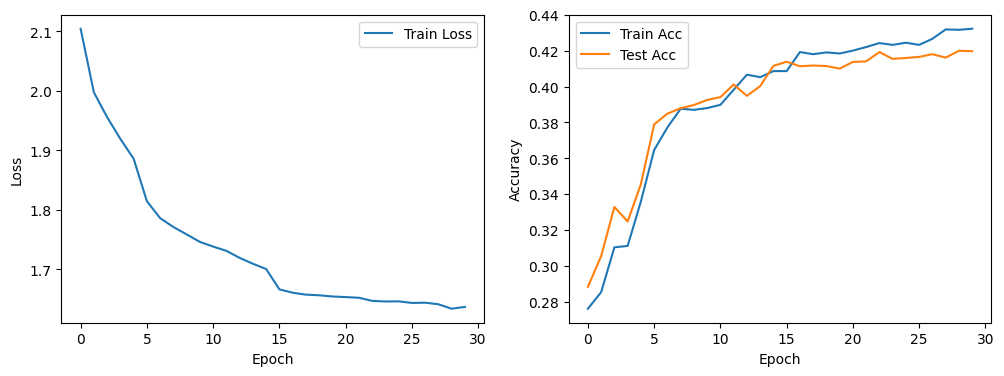

In [60]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [ ]:
print(X_train.shape)   
print(y_train.shape)   
print(X_test.shape)  
print(y_test.shape)   

(50000, 1024)
(50000,)
(10000, 1024)
(10000,)


In [ ]:
xb = Tensor(X_train[:1], label="input")  # batch size = 1
yb = y_train[:1]

logits = model(xb)
loss = logits.cross_entropy_logits(yb)

loss.backward()


In [ ]:
dot = draw_dot(loss)
dot.render("mlp_autograd_graph", view=True)


'mlp_autograd_graph.svg'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CIFAR10_LABELS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def side_by_side_predictions(model, X, y, n=8):
    logits = model(Tensor(X[:n]))
    preds = np.argmax(logits.data, axis=1)

    plt.figure(figsize=(2*n, 3))
    for i in range(n):
        img = X[i].reshape(32, 32)

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        title_color = "green" if preds[i] == y[i] else "red"
        plt.title(
            f"P: {CIFAR10_LABELS[preds[i]]}\n"
            f"T: {CIFAR10_LABELS[y[i]]}",
            color=title_color,
            fontsize=9
        )

    plt.suptitle("CIFAR-10: Side-by-Side Predictions (Green=Correct, Red=Wrong)", fontsize=12)
    plt.show()


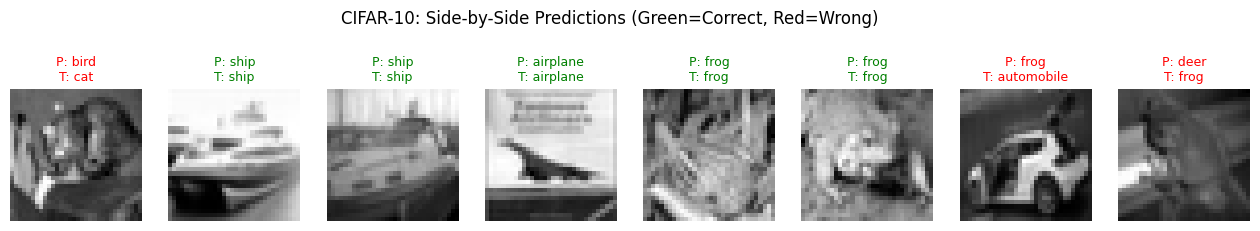

In [ ]:
side_by_side_predictions(model, X_test, y_test, n=8)
